# Good Judgment Project — an *informative* forecaster ranking (Step 4)

The macro applications (SPF/ECB) are the **null-ish regime**: professional macro
forecasters cluster, so the simultaneous rank confidence sets are wide and mostly
`[1, p]`. This notebook is the **informative regime** of the same method: ranking
individual forecasters in the Good Judgment Project (GJP) geopolitical tournament,
where skill genuinely varies (the "superforecaster" result) and the *same* pipeline
confidently separates a top tier.

**Harmony = one method, two regimes.** Nothing in `rankci` changes; only the data
changes, and the method correctly reports "cannot separate" on macro and "top tier
identified" here.

**Why GJP fits the covariance layer exactly.** The panel is `(question x forecaster)`
Brier scores:
- each question's realized outcome is shared by everyone who answered it → a
  **question-level common shock** that cancels in Brier *differences* (this is the
  "standardize Brier within question" step of the GJP papers, done properly);
- forecasters answer different question subsets → an **unbalanced** panel;
- questions ordered by close date give the time axis for the HAC layer (serial
  dependence is mild here — the cross-sectional common shock dominates).

Data: Harvard Dataverse `doi:10.7910/DVN/BPCDH5` (CC0), tournament years 1–2.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rankci.data.gjp import load_gjp_ifps, load_gjp_forecasts, brier_panel
from rankci import (rank_ci_stepwise_pairwise,
                    rank_ci_stepwise_simulation_pairwise,
                    tau_best_from_rank_ci)

ALPHA, B, SEED = 0.2, 5000, 42
pd.set_option("display.width", 170)

## 1. Build the Brier panel (yr1+yr2, top-20 most-active individuals)

In [2]:
ifps = load_gjp_ifps("../../data/gjp/ifps.csv")
fc   = load_gjp_forecasts(["../../data/gjp/survey_fcasts.yr1.csv",
                           "../../data/gjp/survey_fcasts.yr2.csv"])

panel, info = brier_panel(fc, ifps, condition="individual",
                          min_questions=60, top_n=20, years=[1, 2])
X   = panel.values
ids = list(panel.columns)
p   = X.shape[1]
theta = np.nanmean(X, axis=0)          # mean Brier (0 best .. 2 worst)

print(f"panel: {X.shape[0]} questions x {p} forecasters")
print(f"overlap: users/question median={info['users_per_question'].median():.0f}; "
      f"questions/user median={info['questions_per_user'].median():.0f}")
print(f"mean Brier: best={theta.min():.3f}, worst={theta.max():.3f} "
      f"(spread {theta.max()/theta.min():.1f}x)")

panel: 212 questions x 20 forecasters
overlap: users/question median=20; questions/user median=212
mean Brier: best=0.287, worst=0.853 (spread 3.0x)


## 2. Rank confidence intervals — bootstrap, MDS, and Omega

In [3]:
boot = rank_ci_stepwise_pairwise(X, alpha=ALPHA, B=B, seed=SEED, verbose=False)
mds  = rank_ci_stepwise_simulation_pairwise(X, alpha=ALPHA, B=B, seed=SEED,
                                            covariance="mds",   verbose=False)
om   = rank_ci_stepwise_simulation_pairwise(X, alpha=ALPHA, B=B, seed=SEED,
                                            covariance="omega", verbose=False)

tab = pd.DataFrame({
    "user_id":  ids,
    "mean_Brier": theta.round(3),
    "CI_boot":  [f"[{l},{u}]" for l, u in boot["rank_ci"]],
    "CI_mds":   [f"[{l},{u}]" for l, u in mds["rank_ci"]],
    "CI_omega": [f"[{l},{u}]" for l, u in om["rank_ci"]],
}).sort_values("mean_Brier").reset_index(drop=True)
tab.index += 1
tab.index.name = "point rank"
tab

,user_id,mean_Brier,CI_boot,CI_mds,CI_omega
point rank,,,,,
1,803.0,0.287,"[1,3]","[1,3]","[1,3]"
2,1038.0,0.355,"[1,12]","[1,12]","[1,12]"
3,3144.0,0.383,"[2,16]","[2,16]","[2,16]"
4,426.0,0.391,"[2,16]","[2,16]","[2,16]"
5,1000.0,0.397,"[1,16]","[1,16]","[1,17]"
6,3981.0,0.411,"[2,17]","[2,17]","[2,17]"
7,3631.0,0.439,"[2,17]","[2,17]","[2,18]"
8,93.0,0.452,"[2,17]","[2,17]","[2,17]"
9,4113.0,0.452,"[3,17]","[3,17]","[3,17]"


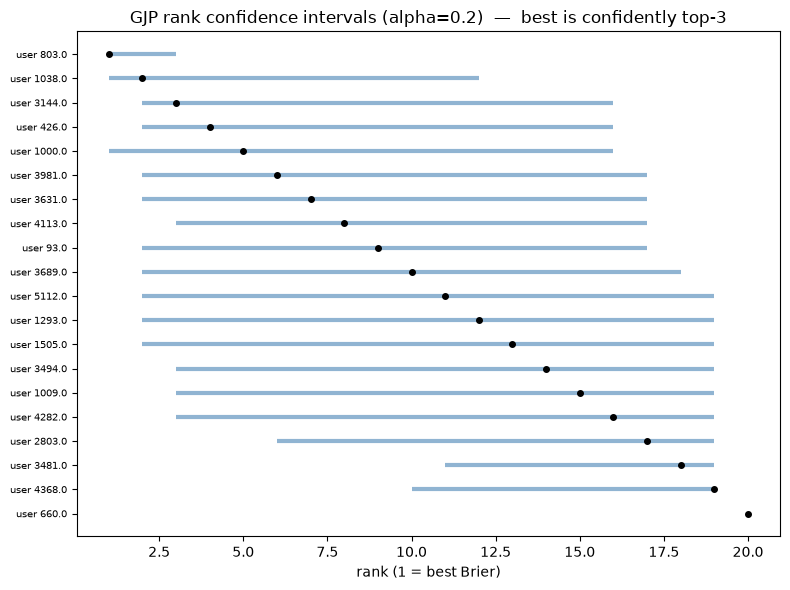

In [4]:
# Caterpillar plot: forecasters sorted best->worst, bootstrap rank-CI bars.
order = np.argsort(theta)
ci = boot["rank_ci"][order]
yy = np.arange(p)
fig, ax = plt.subplots(figsize=(8, 6))
ax.hlines(yy, ci[:, 0], ci[:, 1], color="steelblue", lw=3, alpha=0.6)
ax.plot(np.arange(1, p + 1), yy, "o", color="black", ms=4)  # point rank
ax.set_yticks(yy); ax.set_yticklabels([f"user {ids[i]}" for i in order], fontsize=7)
ax.set_xlabel("rank (1 = best Brier)"); ax.invert_yaxis()
ax.set_title(f"GJP rank confidence intervals (alpha={ALPHA})  —  best is confidently top-{boot['rank_ci'][order][0,1]}")
fig.tight_layout(); plt.show()

## 3. Confidence sets for the top tier (tau-best)

Which forecasters could belong to the top-tau? Projected from the
joint rank CIs of the direct construction (Omega), as reported in the thesis
(`L_j <= tau`: every forecaster whose rank set reaches rank tau or better).

In [5]:
for tau in (1, 3, 5):
    s = tau_best_from_rank_ci(om["rank_ci"], tau)
    members = [ids[j] for j in np.where(s)[0]]
    print(f"tau={tau}: {s.sum():2d} forecasters can be in the top-{tau}  ->  users {members}")

tau=1:  3 forecasters can be in the top-1  ->  users [803.0, 1000.0, 1038.0]
tau=3: 16 forecasters can be in the top-3  ->  users [93.0, 426.0, 803.0, 1000.0, 1009.0, 1038.0, 1293.0, 1505.0, 3144.0, 3494.0, 3631.0, 3689.0, 3981.0, 4113.0, 4282.0, 5112.0]
tau=5: 17 forecasters can be in the top-5  ->  users [93.0, 426.0, 803.0, 1000.0, 1009.0, 1038.0, 1293.0, 1505.0, 2803.0, 3144.0, 3494.0, 3631.0, 3689.0, 3981.0, 4113.0, 4282.0, 5112.0]


## 4. Validation — is the ranking real skill, or luck?

Split the questions into two independent halves (alternating by close date), rank on
each, and correlate. Persistent skill => high rank correlation; pure luck => ~0.

In [6]:
half_a = panel.iloc[0::2]      # alternating questions (already ordered by close date)
half_b = panel.iloc[1::2]
ta = np.nanmean(half_a.values, axis=0)
tb = np.nanmean(half_b.values, axis=0)
from numpy import argsort
def spearman(u, v):
    ru = argsort(argsort(u)); rv = argsort(argsort(v))
    return float(np.corrcoef(ru, rv)[0, 1])
rho = spearman(ta, tb)
top5_a = set(np.argsort(ta)[:5]); top5_b = set(np.argsort(tb)[:5])
print(f"Spearman rank correlation across question halves: {rho:.2f}")
print(f"top-5 overlap across halves: {len(top5_a & top5_b)}/5")
print("=> skill is persistent, not luck" if rho > 0.5 else "=> weak persistence")

Spearman rank correlation across question halves: 0.79
top-5 overlap across halves: 3/5
=> skill is persistent, not luck


## 5. The two regimes — GJP vs macro, same pipeline

Side by side: the informative GJP ranking and the null-ish macro (NGDP) ranking,
both from the identical bootstrap stepwise procedure. Widths are normalised by the
maximum possible width `p-1` so the two panels are comparable.

In [7]:
from rankci import select_top_forecasters
from rankci.data.philly import load_spf, load_rtdsm, compute_error_panel

spf = load_spf("../../data/philly/SPFmicrodata.xlsx", sheet="NGDP")
rt  = load_rtdsm("../../data/philly/NOUTPUTQvQd.xlsx", prefix="NOUTPUT")
Xn  = select_top_forecasters(compute_error_panel(spf, rt, "NGDP", 3, "squared"),
                             N=8, min_obs=20).values
ngdp = rank_ci_stepwise_pairwise(Xn, alpha=ALPHA, B=B, seed=SEED, verbose=False)

def summarise(name, res, Xp):
    ci = res["rank_ci"]; pp = Xp.shape[1]
    w = (ci[:, 1] - ci[:, 0]).mean() / (pp - 1)
    nontrivial = ((ci[:, 0] > 1) | (ci[:, 1] < pp)).mean()
    best = int(np.argmin(np.nanmean(Xp, axis=0)))
    return {"dataset": name, "p": pp, "n_obs": Xp.shape[0],
            "norm_width": round(w, 2),
            "frac_forecasters_separated": round(float(nontrivial), 2),
            "best_forecaster_CI": f"[{ci[best,0]},{ci[best,1]}]"}

pd.DataFrame([summarise("GJP (geopolitical)", boot, X),
              summarise("NGDP (macro)", ngdp, Xn)]).set_index("dataset")

/Users/Parimah/Desktop/ranks-inference-forecasters/.venv/lib/python3.11/site-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


,p,n_obs,norm_width,frac_forecasters_separated,best_forecaster_CI
dataset,,,,,
GJP (geopolitical),20,212,0.68,1.00,"[1,3]"
NGDP (macro),8,225,0.96,0.25,"[1,8]"


## Summary

- **GJP separates.** With 212 questions and genuine skill spread, the simultaneous
  rank CIs are informative: the top forecaster is confidently in a small top tier,
  most forecasters have non-trivial bounds, and the ranking is **persistent** across
  independent question halves (not luck).
- **Macro does not.** The identical pipeline on NGDP returns near-trivial `[1, p]`
  intervals — an honest "cannot separate."
- **Same method, two regimes.** The covariance-estimation layer feeding MRSW behaves
  correctly in both: it reports wide sets when forecasters are indistinguishable and
  narrow sets when they are not. The GJP question-outcome common shock is the
  cleanest real-world instance of the cross-sectional dependence the method models.
- Bootstrap, MDS, and Omega agree here (the top-active panel is dense/near-balanced,
  the regime where the two covariance routes coincide — as the Monte Carlo predicts).